###Model Development: Logistic Regression

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, confusion_matrix, classification_report

#Train Logistic Regression
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
log_reg = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Predictions
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

# Metrics
roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)
print("Logistic Regression Results:")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC : {pr_auc:.4f}")

Logistic Regression Results:
ROC-AUC: 0.6193
PR-AUC : 0.0851


In [ ]:
#Visualize Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Confusion Matrix:
 [[5510 3914]
 [ 233  343]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.58      0.73      9424
           1       0.08      0.60      0.14       576

    accuracy                           0.59     10000
   macro avg       0.52      0.59      0.43     10000
weighted avg       0.91      0.59      0.69     10000



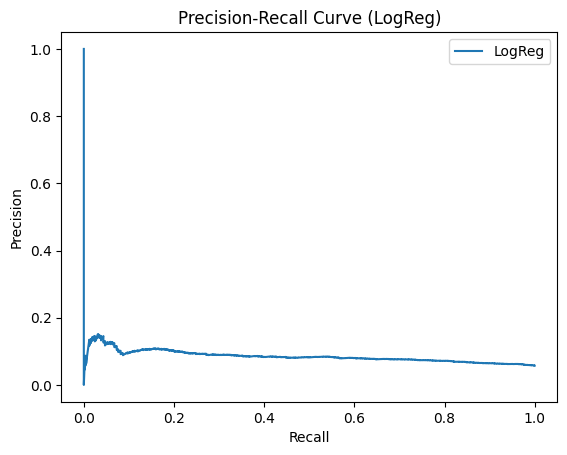

In [ ]:
# Show Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
plt.plot(recall, precision, label="LogReg")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (LogReg)")
plt.legend()
plt.show()

In [ ]:
#Tiered Model Development Strategy
'''
Approach: Start interpretable → Advanced if needed
Priority: High Recall (Safety First) + Manageable Precision
'''

'\nApproach: Start interpretable → Advanced if needed\nPriority: High Recall (Safety First) + Manageable Precision\n'

###Model Development: XGBoost

In [ ]:
# XGBoost with imbalance handling

# Compute imbalance ratio
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb_clf = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False
)

xgb_clf.fit(X_train, y_train)

# Predictions
y_pred_proba_xgb = xgb_clf.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_pred_proba_xgb >= 0.5).astype(int)

# Metrics
roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
pr_auc_xgb = average_precision_score(y_test, y_pred_proba_xgb)
print("XGBoost Results:")
print(f"ROC-AUC: {roc_auc_xgb:.4f}")
print(f"PR-AUC : {pr_auc_xgb:.4f}")

XGBoost Results:
ROC-AUC: 0.5624
PR-AUC : 0.0740


In [ ]:
# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("\nConfusion Matrix:\n", cm_xgb)
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))


Confusion Matrix:
 [[8781  643]
 [ 516   60]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.93      0.94      9424
           1       0.09      0.10      0.09       576

    accuracy                           0.88     10000
   macro avg       0.51      0.52      0.52     10000
weighted avg       0.90      0.88      0.89     10000



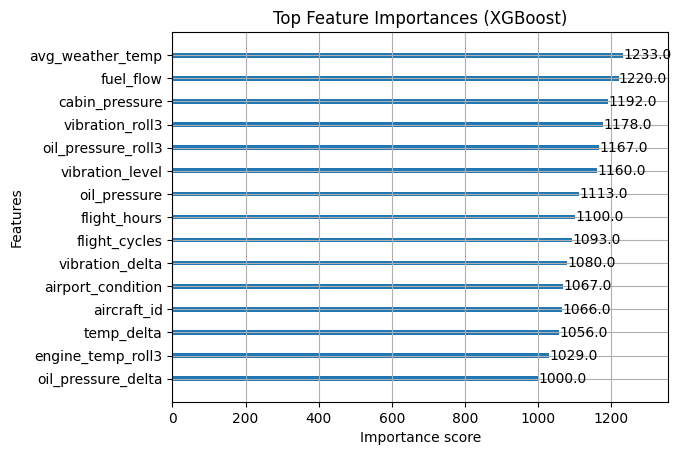

In [ ]:
# Feature Importance
xgb.plot_importance(xgb_clf, max_num_features=15)
plt.title("Top Feature Importances (XGBoost)")
plt.show()

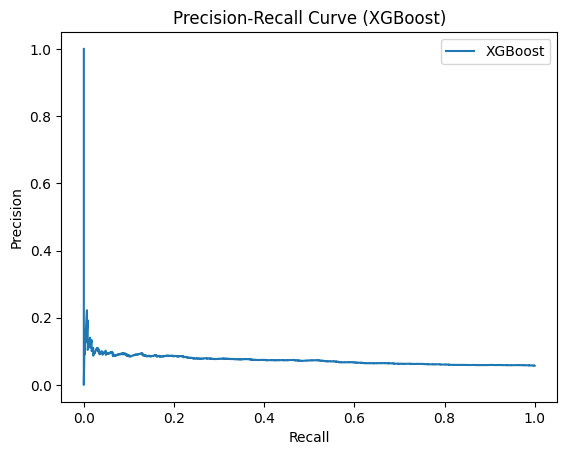

In [ ]:
# Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_xgb)
plt.plot(recall, precision, label="XGBoost")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (XGBoost)")
plt.legend()
plt.show()


###Model Development: LightGBM

In [ ]:
# LightGBM with imbalance handling

lgb_clf = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    is_unbalance=True,   # let LGBM auto-handle imbalance
    random_state=42
)

lgb_clf.fit(X_train, y_train)

# Predictions
y_pred_proba_lgb = lgb_clf.predict_proba(X_test)[:, 1]
y_pred_lgb = (y_pred_proba_lgb >= 0.5).astype(int)

# Metrics
roc_auc_lgb = roc_auc_score(y_test, y_pred_proba_lgb)
pr_auc_lgb = average_precision_score(y_test, y_pred_proba_lgb)
print("LightGBM Results:")
print(f"ROC-AUC: {roc_auc_lgb:.4f}")
print(f"PR-AUC : {pr_auc_lgb:.4f}")

[LightGBM] [Info] Number of positive: 2306, number of negative: 37694
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.017800 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4842
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.057650 -> initscore=-2.793987
[LightGBM] [Info] Start training from score -2.793987
LightGBM Results:
ROC-AUC: 0.5614
PR-AUC : 0.0786


In [ ]:
# Confusion Matrix
cm_lgb = confusion_matrix(y_test, y_pred_lgb)
print("\nConfusion Matrix:\n", cm_lgb)
print("\nClassification Report:\n", classification_report(y_test, y_pred_lgb))


Confusion Matrix:
 [[8591  833]
 [ 493   83]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.91      0.93      9424
           1       0.09      0.14      0.11       576

    accuracy                           0.87     10000
   macro avg       0.52      0.53      0.52     10000
weighted avg       0.90      0.87      0.88     10000



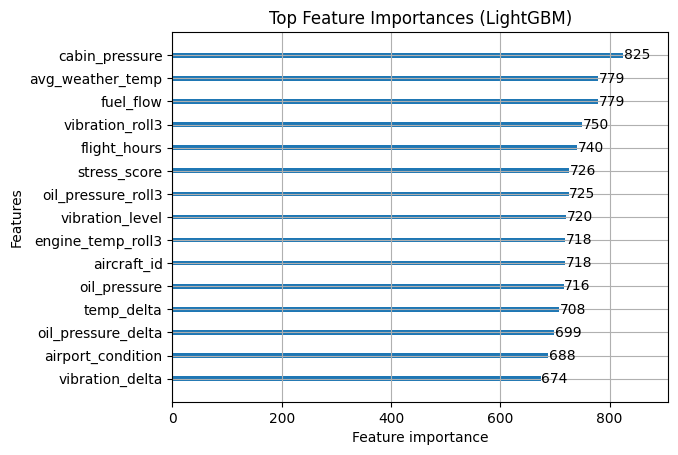

In [ ]:
# Feature Importance
lgb.plot_importance(lgb_clf, max_num_features=15)
plt.title("Top Feature Importances (LightGBM)")
plt.show()

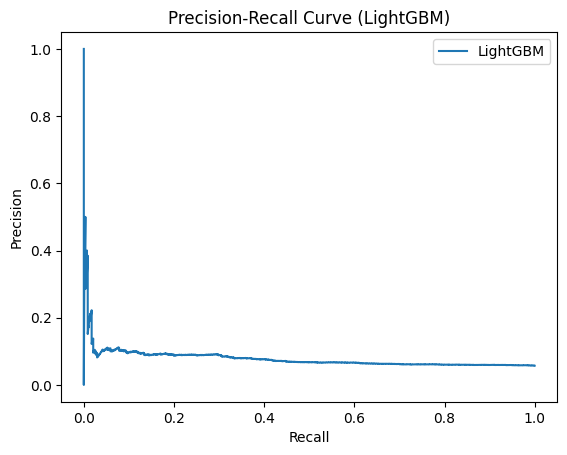

In [ ]:
#Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_lgb)
plt.plot(recall, precision, label="LightGBM")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (LightGBM)")
plt.legend()
plt.show()


In [ ]:
from sklearn.metrics import f1_score, recall_score, precision_score

# Try multiple thresholds
thresholds = np.linspace(0.1, 0.9, 9)
for t in thresholds:
    y_pred_thresh = (y_pred_proba >= t).astype(int) # Assuming y_pred_proba from Logistic Regression
    recall = recall_score(y_test, y_pred_thresh)
    precision = precision_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)
    print(f"Threshold {t:.1f} -> Precision: {precision:.3f}, Recall: {recall:.3f}, F1: {f1:.3f}")

Threshold 0.1 -> Precision: 0.058, Recall: 1.000, F1: 0.109
Threshold 0.2 -> Precision: 0.058, Recall: 1.000, F1: 0.109
Threshold 0.3 -> Precision: 0.060, Recall: 0.984, F1: 0.112
Threshold 0.4 -> Precision: 0.066, Recall: 0.865, F1: 0.123
Threshold 0.5 -> Precision: 0.081, Recall: 0.595, F1: 0.142
Threshold 0.6 -> Precision: 0.094, Recall: 0.236, F1: 0.135
Threshold 0.7 -> Precision: 0.124, Recall: 0.047, F1: 0.068
Threshold 0.8 -> Precision: 0.000, Recall: 0.000, F1: 0.000
Threshold 0.9 -> Precision: 0.000, Recall: 0.000, F1: 0.000
